
<div dir=ltr align=center>

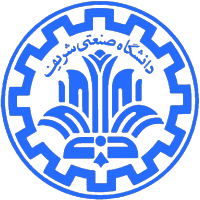

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Linear Algebra <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Hamidreza Rabiee <br>
    Maryam Ramezani <br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 2<br>
    SVD<br>
<font color=696880 size=4>
    Sajad Fathian

____

# <font color='#e74c3c'> Cell 0: The Architect's Duty — Important Instructions</font>

---

<div style='background-color: #2c0b0e; padding: 20px; border-radius: 10px; border-left: 5px solid #e74c3c;'>

> **There are some duties in the markdown text that colored by <span style="color:#e74c3c; font-weight:bold;">RED</span> requires your input.** You must replace the `?` placeholders with the correct values to complete the transformations!

> **In the code parts you should fill the `TODO` parts**

</div>

---

In [ ]:
# ==========================================
# CELL 1: THE ARMORY (Imports & Setup)
# ==========================================

import seaborn as sns
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Print a success message so you know the kernel is ready
print("✅ All libraries successfully imported! The notebook is ready to run.")

✅ All libraries successfully imported! The notebook is ready to run.


# <font color='#b8860b'>🌲 Part 1: The Geometric Intuition - Matrices as Transformation Machines</font>


Before we jump into image compression or complex datasets, let's understand what Singular Value Decomposition (SVD) actually does to space. 

In linear algebra, any matrix $A$ (for example, a $2 \times 2$ matrix) can be thought of as a **transformation machine**. It takes points in space and moves them. If we have a perfect unit circle in 2D space, multiplying those points by matrix $A$ will stretch and rotate that circle into an **ellipse**.

SVD tells us that this complex transformation can always be broken down into three simple, distinct steps:
$$A = U \Sigma V^T$$

1. **$V^T$ (First Rotation):** Rotates the input space to align with the matrix's preferred directions.
2. **$\Sigma$ (Stretching):** Stretches or shrinks the space along the axes. The numbers on the diagonal of this matrix are the **Singular Values**. They tell us exactly how long the major and minor axes of our new ellipse will be!
3. **$U$ (Second Rotation):** Rotates the stretched shape into its final position.

In the code below, we will generate a circle, apply a random transformation matrix to it, and use SVD to magically find and draw the exact principal axes (diameters) of the resulting ellipse.



## <font color='#b8860b'>🌲 Part 1.1: Building the Transformation Matrix</font> 

**Objective:** We want to construct a single $2 \times 3$ matrix ($A$) that transforms a 3D sphere into a 2D ellipse (where the $x$-axis is scaled by 2, and the $z$-axis is flattened), and then rotates that ellipse by $45^\circ$.

#### Step 1: The Scaling & Projection Matrix ($S$)
First, build a $2 \times 3$ matrix that takes a 3D coordinate vector $(x, y, z)$ and scales it:
* **Stretch:** Multiply the $x$-axis by 2.
* **Preserve:** Keep the $y$-axis exactly the same (multiply by 1).
* **Flatten:** Remove the depth along the $z$-axis entirely.

<span style="color:red;">*Write down your matrix $S$:*</span>
$$S = \begin{bmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}$$

#### Step 2: The Rotation Matrix ($R$)
Next, we need to rotate our 2D shape by $45^\circ$. We know you can use the standard 2D rotation matrix formula:
$$R = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$$

<span style="color:red;">*Plug in $\theta = 45^\circ$ to find your matrix $R$ :*</span>
$$R = \begin{bmatrix} 0.7 & -0.7 \\ 0.7 & 0.7 \end{bmatrix}$$

#### Step 3: The Composite Matrix ($A$)
To combine these geometric actions into a single step, we multiply the matrices. Because we want to flatten and scale *first*, and rotate *second*, we must read from **right to left** and multiply $R \times S$.

<span style="color:red;">*Perform the matrix multiplication to find the final composite matrix $A$:*</span>

$$A = R \times S$$

$$A = \begin{bmatrix} 0.7 & -0.7 \\ 0.7 & 0.7 \end{bmatrix} \begin{bmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}$$

$$A = \begin{bmatrix} 1.4 & -0.7 & 0 \\ 1.4 & 0.7 & 0 \end{bmatrix}$$


In [2]:
# Step 1: The Scaling & Projection Matrix (S)
# TODO: Build matrix S using np.array
# Goal: Double the x-axis, preserve the y-axis, and flatten the z-axis.
S = np.array([[2,0,0],[0,1,0]])

# Step 2: The Rotation Matrix (R)
# TODO: Build matrix R using np.array
# Goal: Rotate the 2D shape by 45 degrees.
theta = np.pi / 4
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

# Step 3: The Composite Matrix (A)
# TODO: Use the correct Python matrix multiplication operator to combine R and S.
# Hint: Remember that geometric transformations apply right-to-left!
A = R@S

# --- DO NOT EDIT BELOW THIS LINE --- #
print("--- Matrix S (Scaling & Projection) ---")
print(S)

print("\n--- Matrix R (Rotation 45 Degrees) ---")
print(R)

print("\n--- Final Composite Matrix A ---")
print(A)

--- Matrix S (Scaling & Projection) ---
[[2 0 0]
 [0 1 0]]

--- Matrix R (Rotation 45 Degrees) ---
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

--- Final Composite Matrix A ---
[[ 1.41421356 -0.70710678  0.        ]
 [ 1.41421356  0.70710678  0.        ]]


## <font color='#b8860b'>🌲 Part 1.2: The SVD Breakdown — Geometry in Motion</font>

**Objective:** Decompose any linear transformation matrix $A$ into its three fundamental geometric actions: **Rotation**, **Scaling**, and **Rotation**. This reveals the "skeleton" of how space is morphed.



#### 1. The General Theory: How SVD Transforms Space
Any linear transformation $A$ can be decomposed into $A = U \Sigma V^T$. Regardless of the dimensions of the matrix, the transformation always follows this rigid geometric sequence:

1.  **Alignment ($V^T$):** The first step is a rotation in the domain space. $V^T$ pivots the input coordinate system to align with the directions that will eventually be the principal axes of the transformed shape.
2.  **Stretching & Squashing ($\Sigma$):** This is the heart of the transformation. $\Sigma$ is a diagonal matrix that scales space along those aligned axes. If the target space has fewer dimensions than the input space, $\Sigma$ effectively "squashes" the unnecessary dimensions (like the $z$-axis) to zero.
3.  **Final Orientation ($U$):** The final step is a rotation in the target space. $U$ takes the stretched/squashed shape and rotates it into its final position and orientation.

---

#### 2. Application: Visualizing our Transformation
Now, we return to the specific matrix **$A$** that you constructed in Part 1.1. We want to see this general theory manifest step-by-step for our specific case. 

We will decompose our matrix $A$ and track both the **3D Sphere** and the **Basis Vectors ($i, j, k$)** as they undergo this exact sequence:

* **Step 1 ($V^T$):** See how the sphere rotates to prepare for the squash.
* **Step 2 ($\Sigma$):** Observe the sphere flattening into a 2D ellipse as the $z$-axis vanishes.
* **Step 3 ($U$):** Watch the final rotation that locks your ellipse into its $45^\circ$ orientation.


<>:67: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:67: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_7144\2735140451.py:67: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  titles = ["1. Original Sphere", "2. After $V^T$ (3D Rotation)", "3. After $\Sigma$ (Squash to 2D)", "4. After $U$ (2D Rotation)"]



--- Matrix V^T (The Initial 3D Alignment) ---
[[-1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

--- Singular Values ---
[2. 1.]

--- Matrix Sigma (The Scaling & Dimensionality Reduction) ---
[[2. 0. 0.]
 [0. 1. 0.]]

--- Matrix U (The Final 2D Rotation) ---
[[-0.707 -0.707]
 [-0.707  0.707]]


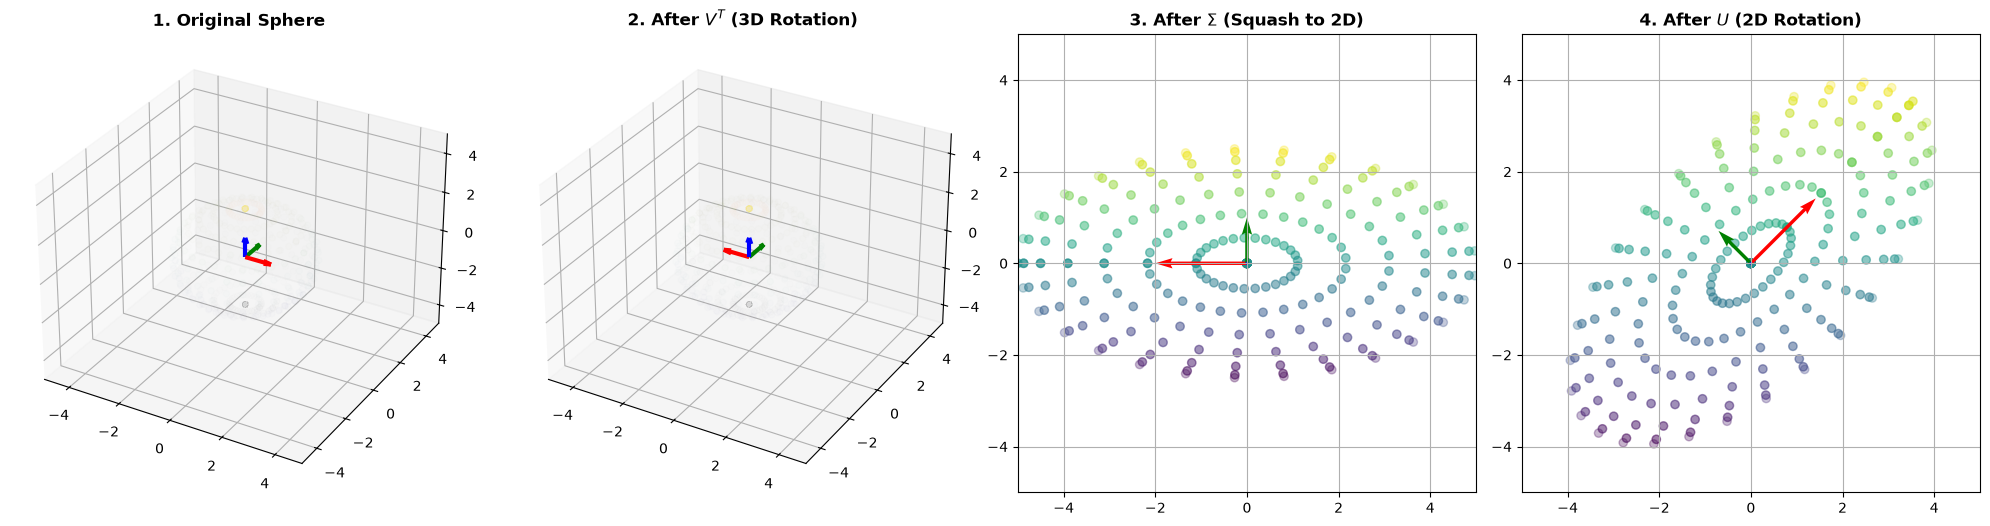

In [4]:
# 1. Generate a 3D Sphere (The Input)
radius = 2.5  
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
sphere = radius * np.vstack((np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v))).reshape(3, -1)

# ==============================================================
# TODO 1: Perform the SVD Decomposition
# Use numpy's linear algebra library to decompose matrix A. (np.linalg.svd(A))
# ==============================================================

U, S, VT = np.linalg.svd(A)

# ==============================================================
# TODO 2: Build the Sigma Matrix
# 'S' is just a 1D array of numbers. Create matrix called 'Sigma' with full dimension
# and place the values of 'S' on its main diagonal.
# ==============================================================
Sigma = np.array([[S[0],0,0],[0,S[1],0]])

# ==============================================================
# Print the hidden mechanics discovered by SVD
# ==============================================================
print("\n--- Matrix V^T (The Initial 3D Alignment) ---")
print(np.round(VT, 3))

print("\n--- Singular Values ---")
print(np.round(S, 3))

print("\n--- Matrix Sigma (The Scaling & Dimensionality Reduction) ---")
print(np.round(Sigma, 3))

print("\n--- Matrix U (The Final 2D Rotation) ---")
print(np.round(U, 3))




# Define 3D Basis Vectors [i, j, k] (The "Skeleton" of our space)
basis = np.eye(3)

# ==============================================================
# TODO 3: The Geometric Pipeline
# Apply the SVD matrices to the 'sphere' step-by-step.
# Remember: Apply transformations from right to left! (VT, then Sigma, then U)
# Use the '@' operator for matrix multiplication.
# ==============================================================
stage_1_original = sphere
stage_2_rotated = VT @ stage_1_original      # Apply VT to the sphere
stage_3_squashed = Sigma @ stage_2_rotated   # Apply Sigma to stage_2
stage_4_final    = U @ stage_3_squashed      # Apply U to stage_3

stages = [stage_1_original, stage_2_rotated, stage_3_squashed, stage_4_final]

# ==============================================================
# TODO 4: Transform the Basis Vectors (The "Skeleton")
# Now, apply the exact same sequence of transformations to the 'basis' vectors.
# This will visually demonstrate how the X, Y, and Z axes are rotated and squashed.
# Hint: Use the '@' operator, just like you did for the sphere!
# ==============================================================
basis_1_original = basis
basis_2_rotated  = VT@basis_1_original  # Apply VT to basis_1_original
basis_3_squashed = Sigma@basis_2_rotated  # Apply Sigma to basis_2_rotated
basis_4_final    = U@basis_3_squashed  # Apply U to basis_3_squashed

basis_stages = [basis_1_original, basis_2_rotated, basis_3_squashed, basis_4_final]

titles = ["1. Original Sphere", "2. After $V^T$ (3D Rotation)", "3. After $\Sigma$ (Squash to 2D)", "4. After $U$ (2D Rotation)"]

# ==============================================================
# 5. Plotting everything (DO NOT EDIT THIS SECTION)
# ==============================================================
fig = plt.figure(figsize=(20, 5))

for i, stage in enumerate(stages):
    is_3d = (stage.shape[0] == 3)
    ax = fig.add_subplot(1, 4, i+1, projection='3d' if is_3d else None)
    
    if is_3d:
        ax.scatter(stage[0], stage[1], stage[2], c=stage[2], cmap='viridis', alpha=0.1)
        ax.set_xlim([-5, 5]); ax.set_ylim([-5, 5]); ax.set_zlim([-5, 5]) 
    else:
        ax.scatter(stage[0], stage[1], c=stage[1], cmap='viridis', alpha=0.3)
        ax.set_xlim([-5, 5]); ax.set_ylim([-5, 5]) 
        ax.grid(True)
        ax.set_aspect('equal') 
    
    b = basis_stages[i]
    colors = ['r', 'g', 'b']
    for j in range(b.shape[1]):
        vec = b[:, j]
        if is_3d:
            ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=colors[j], linewidth=3)
        else:
            ax.quiver(0, 0, vec[0], vec[1], color=colors[j], angles='xy', scale_units='xy', scale=1, linewidth=3)
            
    ax.set_title(titles[i], fontweight='bold')

plt.tight_layout()
plt.show()

# <font color='#8a9a5b'>🧩 Part 2: Image Compression — Keeping Only What Matters</font>

Now that we have seen how SVD transforms and stretches space geometrically, let's use the exact same idea to solve a real problem:

**How can we store an image using much less information while preserving most of what we see?**

An image is actually just a matrix. For a grayscale image:

$$
A \in \mathbb{R}^{m\times n}
$$

Each entry of the matrix represents the brightness of one pixel:
- 0 → black
- 255 → white
- values in between → shades of gray

Instead of storing every pixel directly, Singular Value Decomposition lets us rewrite the image as:

$$
A = U\Sigma V^T
$$

This decomposition reveals something surprising: The image can be represented as a sum of **rank-1 image layers**.

$$
A = \sigma_1u_1v_1^T + \sigma_2u_2v_2^T + \cdots + \sigma_ru_rv_r^T
$$

Each term adds more visual detail to the image. The singular values:

$$
\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r
$$

measure how important each layer is.

* **Large singular values capture:** major shapes, strong contrasts, and overall structure.
* **Small singular values capture:** tiny details, textures, and noise.

---

## The Compression Idea

Instead of keeping every singular value, we keep only the first $k$ largest ones. This creates an approximation:

$$
A_k = U_k\Sigma_kV_k^T
$$

where:
- $U_k$ → first $k$ columns of $U$
- $\Sigma_k$ → first $k$ singular values
- $V_k^T$ → first $k$ rows of $V^T$

This is called the **rank-k approximation**.

---

## Why Does This Compress the Image?

Originally, storing the image requires $m \times n$ numbers.

After SVD compression, we only store $k(m+n+1)$ numbers:
- $mk$ numbers for $U_k$
- $k$ singular values
- $nk$ numbers for $V_k$

If $k \ll \min(m,n)$, then we save a huge amount of storage.

---

## Measuring Information: The "Energy" of an Image

How do we know what value to choose for $k$? We measure the **Energy**. 

In linear algebra and signal processing, "energy" is a mathematical term for *information* or *variance*. The amount of information contained in each layer is proportional to the square of its singular value ($\sigma_i^2$).

To mathematically measure how much of the original image's "essence" we have kept, we calculate the **Cumulative Energy Ratio**:

$$
\text{Energy Retained} = \frac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{r} \sigma_i^2}
$$

This gives us a percentage (like $0.98$ or $98\%$). It allows us to set a target—like keeping 98% of the visual information—and let the math dictate exactly how many singular values ($k$) we need to achieve it.

---

## What Will We Observe?

As we gradually increase $k$:
- **Small $k$:** Blurry image but very high compression.
- **Medium $k$:** Most important features appear.
- **Large $k$:** Image becomes almost identical to the original.

Our goal is to answer: > *How much information can we remove before humans notice?*

In the code below, we will:
1. Load an image as a matrix.
2. Compute its Singular Value Decomposition.
3. Reconstruct the image using different values of $k$.
4. Calculate the **Energy** to find the exact $k$ needed to keep 98% of the information.
5. Compare the visual quality, matrix reduction, and actual file sizes on our disk.

Original file size on disk: 2890.47 KB
Image matrix shape: (1024, 1536)


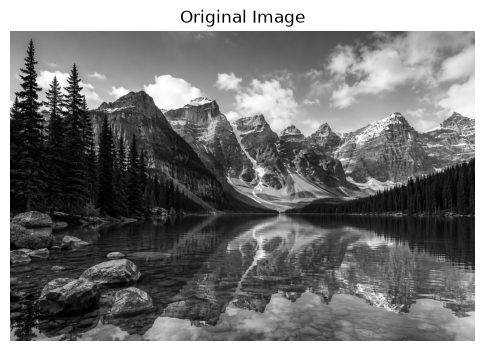

Number of singular values: 1024


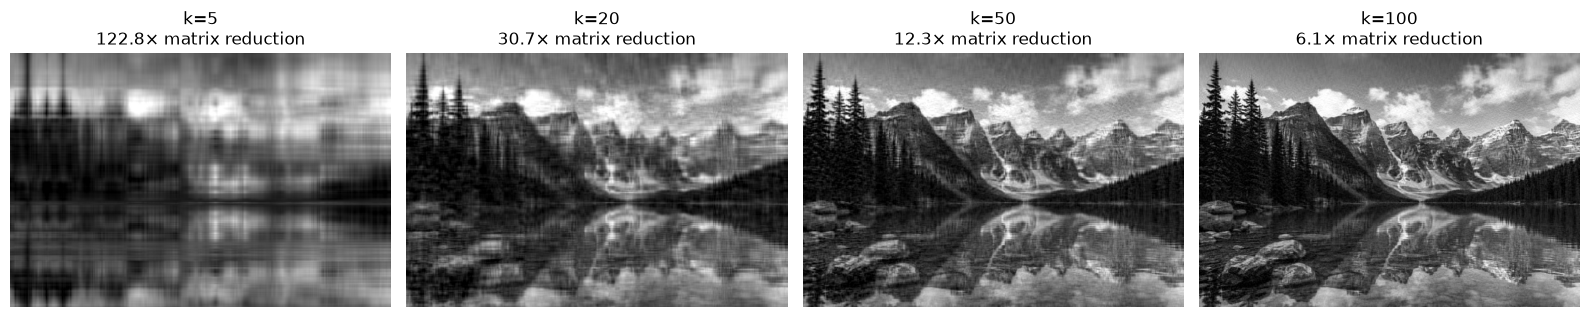

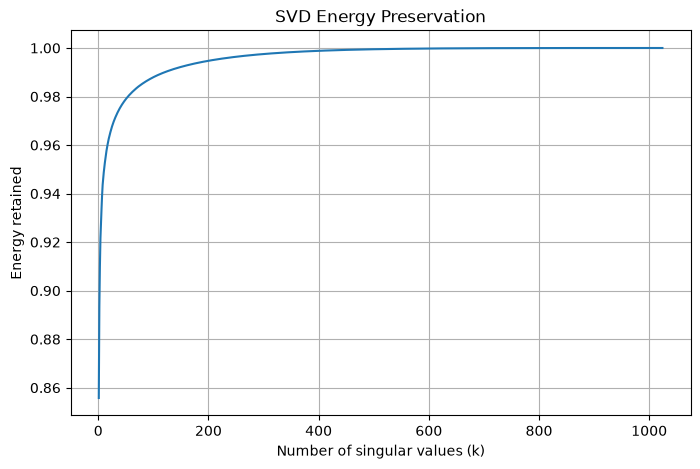

98% energy achieved at k = 54


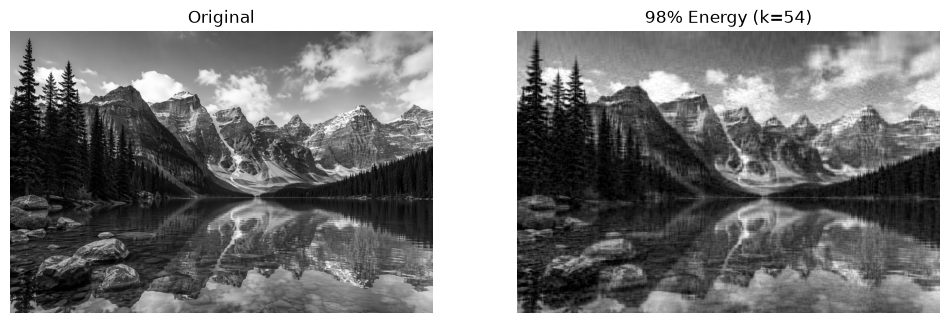

Saved as compressed_output.jpg
Final compressed file size on disk: 193.13 KB
Actual disk space is 15.0x smaller


In [5]:
# ==============================================================
# 1. Load the Image
# ==============================================================
IMAGE_PATH = "gray-nature.png"

if not os.path.exists(IMAGE_PATH):
    print(f"⚠️ Error: Could not find '{IMAGE_PATH}'. Please add an image to your folder.")
else:
    # Check original file size on disk
    original_file_size_kb = os.path.getsize(IMAGE_PATH) / 1024

    img = Image.open(IMAGE_PATH).convert("L")
    A = np.array(img, dtype=float)

    print(f"Original file size on disk: {original_file_size_kb:.2f} KB")
    print("Image matrix shape:", A.shape)

    # Show original image (DO NOT EDIT)
    plt.figure(figsize=(6, 6))
    plt.imshow(A, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    # ==============================================================
    # TODO 1: Compute SVD
    # Use numpy to decompose the image matrix A. 
    # Keep 'full_matrices=False' to save memory.
    # ==============================================================
    U, S, VT = np.linalg.svd(A,full_matrices=False)

    print("Number of singular values:", len(S))

    # ==============================================================
    # TODO 2: The Compression Function
    # Slice the matrices to keep only the top 'k' components, 
    # then multiply them back together to form the compressed image.
    # ==============================================================
    def compress_image(U, S, VT, k):
        # 1. Slice the matrices (Keep first k columns of U, first k values of S, first k rows of VT)
        Uk = U[:, :k]
        Sk = np.diag(S[:k]) 
        VTk = VT[:k, :]

        # 2. Reconstruct the image (Multiply Uk, Sk, VTk right-to-left)
        compressed = Uk@Sk@VTk

        # Ensure pixel values stay valid (0 to 255)
        compressed = np.clip(compressed, 0, 255)
        return compressed


    # ==============================================================
    # TODO 3: Calculate the Storage Ratio
    # Compare how many numbers are stored in the original matrix A 
    # vs. the compressed SVD matrices (Uk, Sk, VTk).
    # ==============================================================
    k_values = [5, 20, 50, 100]
    
    plt.figure(figsize=(16, 5))
    for i, k in enumerate(k_values):
        compressed = compress_image(U, S, VT, k)
        plt.subplot(1, len(k_values), i + 1)
        plt.imshow(compressed, cmap="gray")
        
        m, n = A.shape
        
        # Calculate how many total elements are in original vs compressed
        original_storage = n*m 
        compressed_storage = (m+n+1)*k
        
        ratio = original_storage / compressed_storage
        
        plt.title(f"k={k}\n{ratio:.1f}× matrix reduction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


    # ==============================================================
    # TODO 4: Calculate Energy Retained
    # Energy is the square of the singular values.
    # Calculate the cumulative energy ratio at every step k.
    # ==============================================================
    # Hint: Use np.cumsum() for a running total, divided by the total sum
    # energy should be an array with the values for every k.
    energy = np.cumsum(S**2) / np.sum(S**2)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(S) + 1), energy)
    plt.xlabel("Number of singular values (k)")
    plt.ylabel("Energy retained")
    plt.title("SVD Energy Preservation")
    plt.grid()
    plt.show()

    # ==============================================================
    # TODO 5: Find the minimum k for 98% Energy
    # Find the first index where energy >= 0.98.
    # ==============================================================
    # Hint: np.argmax(energy >= 0.98) returns the first True index.
    # Don't forget to add 1 because indices are 0-based but k represents a count!
    k98 =  np.argmax(energy >= 0.98)+1

    print(f"98% energy achieved at k = {k98}")

    # ==============================================================
    # Show 98% compressed image & Evaluate Disk Space (DO NOT EDIT)
    # ==============================================================
    best = compress_image(U, S, VT, k98)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(A, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(best, cmap="gray")
    plt.title(f"98% Energy (k={k98})")
    plt.axis("off")
    plt.show()

    # Save compressed image
    OUTPUT_PATH = "compressed_output.jpg"
    output = Image.fromarray(best.astype(np.uint8))
    output.save(OUTPUT_PATH)

    # Check compressed file size on disk
    compressed_file_size_kb = os.path.getsize(OUTPUT_PATH) / 1024

    print(f"Saved as {OUTPUT_PATH}")
    print(f"Final compressed file size on disk: {compressed_file_size_kb:.2f} KB")

    disk_ratio = original_file_size_kb / compressed_file_size_kb
    print(f"Actual disk space is {disk_ratio:.1f}x smaller")

# <font color='#5f9ea0'>💠 Part 3: The $1 Million Equation (The Netflix Algorithm)</font>

---

### The Netflix Prize (2006)
In 2006, Netflix was still mailing DVDs to people's houses. To improve their *Cinematch* recommendation system, they launched a global competition: they released an anonymized dataset of **100 million movie ratings** and offered a **$1,000,000 prize** to anyone who could improve the algorithm's accuracy by just 10%. 

For months, the world's best data scientists struggled. The core problem was the **Sparsity of the Matrix**. 
Imagine a grid with 480,000 users (rows) and 17,000 movies (columns). Because nobody has watched every movie in existence, **99% of this massive matrix was completely empty (zeros)**. 

How do you mathematically predict the empty spaces? The answer was a brilliant adaptation of the math you just learned: **Singular Value Decomposition**.

---

### How SVD Reads Minds: "Latent Features"

When we apply SVD to a ratings matrix ($A$), the algorithm breaks human behavior down into three distinct components: $A = U \Sigma V^T$. 

The math doesn't know what the words "Action," "Romance," or "Comedy" mean. Instead, it looks at the numbers and groups movies that are liked by the same types of people into hidden mathematical categories called **Latent Features**.

1. **$U$ (The User Profile):** Tells us *how much each user aligns with each hidden feature*. (e.g., User $i$ loves Feature 1, but hates Feature 2).
2. **$\Sigma$ (The Feature Weight):** Tells us *the global importance of each feature*. (e.g., Feature 1 drives 40% of all ratings on the platform).
3. **$V^T$ (The Movie DNA):** Tells us *how much of each feature a movie contains*. (e.g., "The Matrix" is 90% Feature 1).

---

### The Magic Trick: Predicting the Future

Once we have our truncated, low-rank matrices ($k$), predicting a user's rating for an unseen movie becomes a simple **Dot Product**. 

To predict what Eve will rate *Inception*, the math takes Eve's user profile row from $U_k \Sigma_k$ and calculates the dot product with *Inception*'s movie DNA column from $V_k^T$. If Eve's tastes align mathematically with the movie's DNA, the dot product produces a high number (like 4.8 stars). **The zeros disappear, replaced by highly accurate predictions.** ---

### Your Turn: Student Tasks
In the code below, you will step into the shoes of a data scientist. Your challenges:

1. **Compute & Truncate:** Calculate the SVD and experiment with the Rank ($k$) to see how the algorithm learns patterns instead of just memorizing data.
2. **Predict the Matrix:** Reconstruct the matrix using your truncated components to fill in the "zeros" with predicted ratings.
3. **The Manual Verification:** Prove the magic works by extracting the exact User Profile and Movie DNA to calculate the dot product for Eve's prediction yourself!

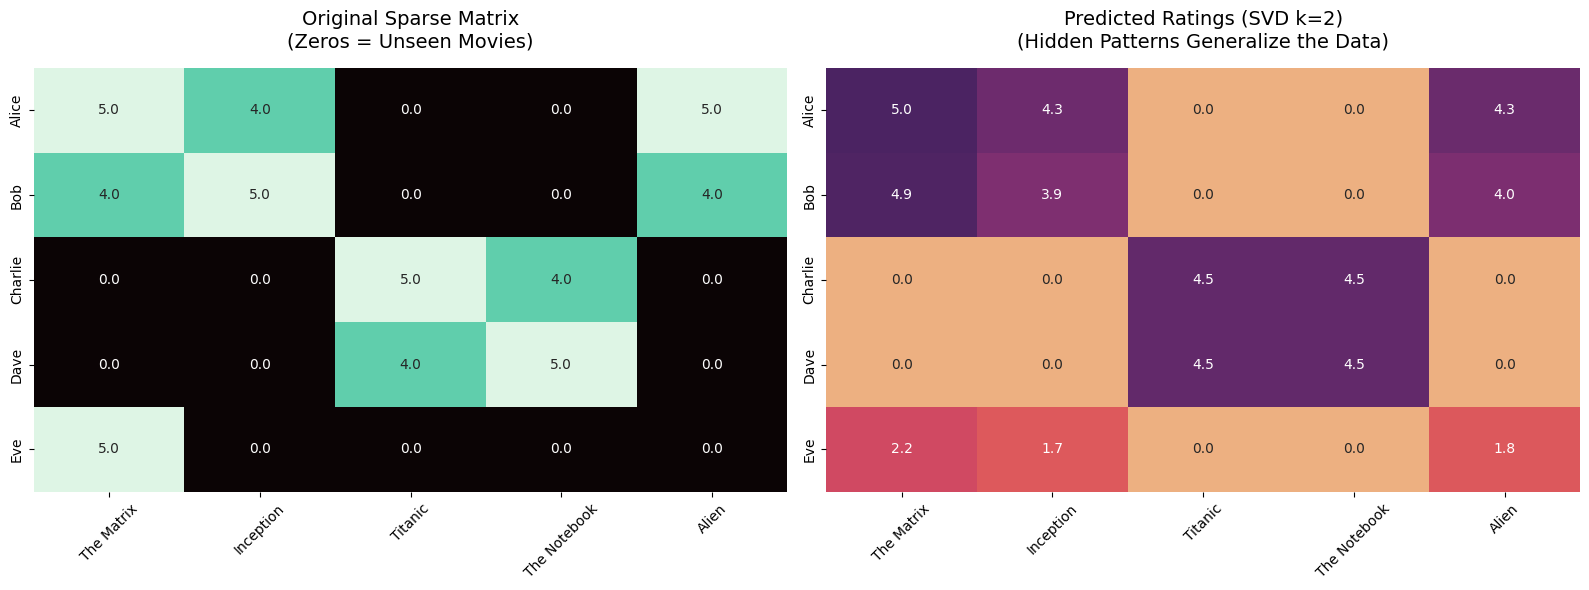

 🎬 EVE'S WATCH HISTORY
Watched: ['The Matrix']

 🍿 SVD RECOMMENDATIONS FOR EVE
- Alien           : Expected Rating 1.76 Stars
- Inception       : Expected Rating 1.74 Stars
- Titanic         : Expected Rating 0.00 Stars
- The Notebook    : Expected Rating 0.00 Stars

✨ SVD TOP PICK: **Alien** ✨


 🧮 MANUAL MATH VERIFICATION
Manual Prediction for Eve & Inception: 1.74 Stars
Does it match the heatmap? It should!


In [ ]:
# ==============================================================
# 1. Create the Sparse User-Movie Matrix
# 0 means the user has NOT watched the movie yet.
# ==============================================================
users = ["Alice", "Bob", "Charlie", "Dave", "Eve"]
movies = ["The Matrix", "Inception", "Titanic", "The Notebook", "Alien"]

# The Hidden Patterns:
# - Alice & Bob love Sci-Fi / Action.
# - Charlie & Dave love Romance / Drama.
ratings = np.array([
    [5, 4, 0, 0, 5],  # Alice
    [4, 5, 0, 0, 4],  # Bob
    [0, 0, 5, 4, 0],  # Charlie
    [0, 0, 4, 5, 0],  # Dave
    [5, 0, 0, 0, 0]   # Eve
], dtype=float)

df_original = pd.DataFrame(ratings, index=users, columns=movies)

# ==============================================================
# 2. Compute SVD and Truncate
# ==============================================================
# TODO 1: Compute the SVD of the ratings matrix.
# Hint: Use np.linalg.svd with full_matrices=False to avoid unnecessary calculations.
# --------------------------------------------------------------
U, S, VT = None, None, None

# --------------------------------------------------------------
# TODO 2: The Rank Experiment
# We use k=2 to force the math to generalize. 
# Change k to 5 (Full Rank), run the code, and look at the Predicted Matrix.
# What happens to the zeros? Why does this ruin our predictions?
# --------------------------------------------------------------
k = None
U_k = None
S_k = None
VT_k = None

# ==============================================================
# 3. Reconstruct to Predict the Zeros
# Formula: A_predicted = U_k * Sigma_k * VT_k
# ==============================================================
predicted_ratings = None

predicted_ratings = np.clip(predicted_ratings, 0, 5)
df_predicted = pd.DataFrame(predicted_ratings, index=users, columns=movies)

# ==============================================================
# 4. Visualize the Magic & Extract Profile
# ==============================================================
if predicted_ratings is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(df_original, annot=True, cmap="mako", cbar=False, ax=axes[0], fmt=".1f")
    axes[0].set_title("Original Sparse Matrix\n(Zeros = Unseen Movies)", fontsize=14, pad=15)
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(df_predicted, annot=True, cmap="flare", cbar=False, ax=axes[1], fmt=".1f")
    axes[1].set_title(f"Predicted Ratings (SVD k={k})\n(Hidden Patterns Generalize the Data)", fontsize=14, pad=15)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # ==============================================================
    # 5. Extract Eve's Recommendation Profile
    # ==============================================================
    eve_original = df_original.loc["Eve"]
    eve_predicted = df_predicted.loc["Eve"]

    print("="*60)
    print(" 🎬 EVE'S WATCH HISTORY")
    print("="*60)
    print(f"Watched: {eve_original[eve_original > 0].index.tolist()}\n")

    unseen_movies = eve_original[eve_original == 0].index
    recommendations = eve_predicted[unseen_movies].sort_values(ascending=False)

    print("="*60)
    print(" 🍿 SVD RECOMMENDATIONS FOR EVE")
    print("="*60)
    for movie, rating in recommendations.items():
        print(f"- {movie.ljust(15)} : Expected Rating {rating:.2f} Stars")
    print(f"\n✨ SVD TOP PICK: **{recommendations.idxmax()}** ✨\n")

else:
    print("⚠️  Complete TODO 1, 2, and 3 to unlock the Heatmaps and Recommendations!  ⚠️")


# ==============================================================
# 6. TODO 3: The Manual Verification (Dot Product)
# Can you calculate Eve's predicted rating for "Inception" manually?
# Hint: Multiply Eve's Profile Row by Inception's DNA Column.
# ==============================================================
print("\n" + "="*60)
print(" 🧮 MANUAL MATH VERIFICATION")
print("="*60)

# Eve is at index 4 in the users list. Inception is at index 1 in the movies list.
# 1. Create the combined User Profile matrix: U_k @ S_k
user_profiles = None

# 2. Extract Eve's specific profile (Row 4)
eve_profile = None

# 3. Extract Inception's DNA (Column 1 of VT_k)
inception_dna = None

# 4. Calculate the Dot Product
manual_prediction = None

print(f"Manual Prediction for Eve & Inception: {manual_prediction:.2f} Stars")
print("Does it match the heatmap? It should!")